# Анализ данных диспансеризации: Прогнозирование рисков ССЗ и диабета

## Описание задания
В этом ноутбуке мы выполняем анализ медицинских данных 1000 пациентов для:
1. **Исследовательский анализ данных (EDA)** - изучение распределений и корреляций
2. **PCA анализ** - выявление скрытых профилей риска
3. **SVM классификация** - прогноз сердечно-сосудистого риска
4. **Fuzzy KNN** - оценка неопределённости риска прогрессии в диабет

> **Задача для обучающегося**: Улучшите это базовое решение, добавив:
> - Дополнительные метрики качества моделей
> - Визуализации для интерпретации результатов
> - Кросс-валидацию и подбор гиперпараметров
> - Обработку пропущенных значений более сложными методами

---

## Импорт библиотек

In [1]:
# Базовые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Библиотеки для машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_curve, auc, confusion_matrix,
    classification_report
)

# Настройки отображения
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_palette("husl")

print("Все библиотеки импортированы")

Все библиотеки импортированы


## Загрузка и первичный осмотр данных

In [2]:
# Загрузка данных
df = pd.read_csv(r'C:\Users\andri\Desktop\Сеченовка\final_task_1_table\dataset\task_1_dispensarization_data_2026.csv')

# Базовая информация о датасете
print(f" Размер датасета: {df.shape[0]} пациентов × {df.shape[1]} признаков")
print(f"\n Названия столбцов:")
print(df.columns.tolist())

# Первые 5 строк для ознакомления
print(f"\n Пример данных:")
display(df.head())

# Проверка пропусков
print(f"\n Пропущенные значения:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "Нет пропущенных значений")

# Статистика по числовым признакам
print(f"\n Базовая статистика:")
display(df.describe().T)

 Размер датасета: 1000 пациентов × 18 признаков

 Названия столбцов:
['Возраст', 'Пол_мужской', 'ИМТ', 'Окружность_талии_см', 'САД_мм_рт_ст', 'ДАД_мм_рт_ст', 'Пульсовое_давление', 'Глюкоза_натощак_ммоль_л', 'HbA1c_%', 'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Триглицериды_ммоль_л', 'СКФ_мл_мин', 'Курение', 'Физическая_активность_мин_нед', 'ССЗ_риск_высокий', 'Статус_глюкозы', 'Доклинический_риск']

 Пример данных:


,Возраст,Пол_мужской,ИМТ,Окружность_талии_см,САД_мм_рт_ст,ДАД_мм_рт_ст,Пульсовое_давление,Глюкоза_натощак_ммоль_л,HbA1c_%,ЛПНП_ммоль_л,ЛПВП_ммоль_л,Триглицериды_ммоль_л,СКФ_мл_мин,Курение,Физическая_активность_мин_нед,ССЗ_риск_высокий,Статус_глюкозы,Доклинический_риск
0,41,1,24.240,81.040,113.190,62.540,50.650,4.595,4.650,NaN,NaN,1.379,115.520,0,165.800,0,0,0
1,46,0,22.880,80.540,117.320,62.110,55.210,4.964,4.000,2.443,1.269,1.903,97.720,0,195.000,0,0,0
2,64,0,21.990,78.420,121.250,71.460,49.790,4.713,5.030,4.213,NaN,NaN,81.540,0,193.200,1,0,0
3,53,0,19.840,73.440,119.750,71.590,48.150,4.431,5.080,2.268,2.022,1.467,93.390,0,248.100,0,0,0
4,53,1,24.280,82.060,127.070,70.340,56.730,4.997,5.040,2.459,1.325,0.967,88.410,0,230.500,0,0,0



 Пропущенные значения:
ЛПНП_ммоль_л            45
ЛПВП_ммоль_л            56
Триглицериды_ммоль_л    61
СКФ_мл_мин              61
dtype: int64

 Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
Возраст,1000.000,52.389,7.586,40.000,46.000,53.000,59.000,65.000
Пол_мужской,1000.000,0.442,0.497,0.000,0.000,0.000,1.000,1.000
ИМТ,1000.000,23.557,3.215,16.000,21.160,23.575,25.852,33.890
Окружность_талии_см,1000.000,86.166,6.007,68.860,82.038,86.130,90.492,104.630
САД_мм_рт_ст,1000.000,114.176,10.987,90.000,106.883,114.530,121.580,147.970
ДАД_мм_рт_ст,1000.000,70.428,7.147,50.000,65.328,70.390,75.312,90.620
Пульсовое_давление,1000.000,43.747,10.441,9.060,36.808,43.965,50.703,73.950
Глюкоза_натощак_ммоль_л,1000.000,5.067,0.756,3.500,4.531,5.014,5.581,7.348
HbA1c_%,1000.000,5.015,0.364,4.000,4.770,5.000,5.280,6.020
ЛПНП_ммоль_л,955.000,2.998,0.649,1.207,2.570,2.999,3.427,5.247


## 🔍 Исследовательский анализ данных (EDA)

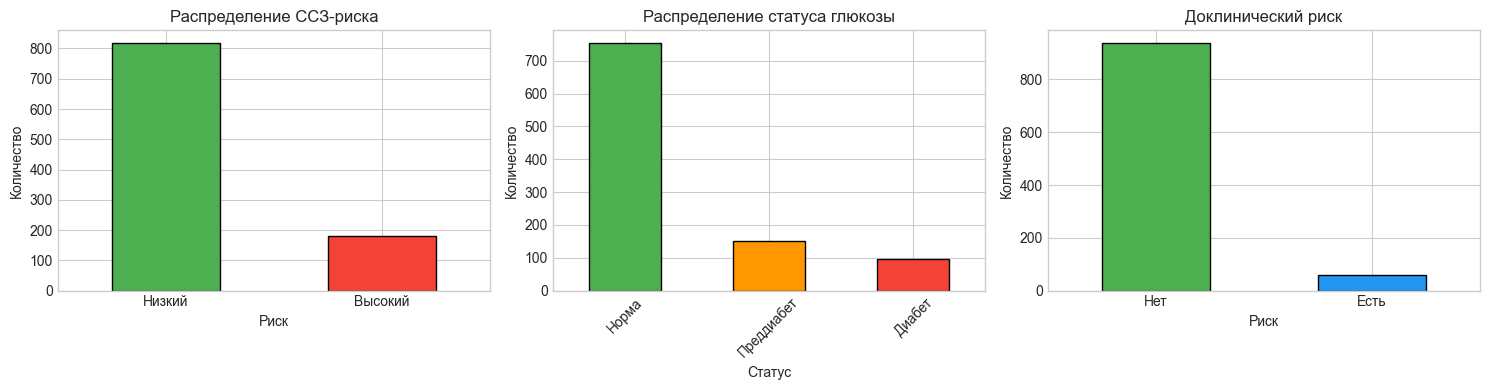

In [3]:
# Распределение целевых переменных
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Сердечно-сосудистый риск
df['ССЗ_риск_высокий'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'], edgecolor='black'
)
axes[0].set_title('Распределение ССЗ-риска')
axes[0].set_xlabel('Риск')
axes[0].set_ylabel('Количество')
axes[0].set_xticklabels(['Низкий', 'Высокий'], rotation=0)

# 2. Статус глюкозы
status_map = {0: 'Норма', 1: 'Преддиабет', 2: 'Диабет'}
df['Статус_глюкозы'].map(status_map).value_counts().plot(
    kind='bar', ax=axes[1], color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='black'
)
axes[1].set_title('Распределение статуса глюкозы')
axes[1].set_xlabel('Статус')
axes[1].set_ylabel('Количество')
axes[1].tick_params(axis='x', rotation=45)

# 3. Доклинический риск
df['Доклинический_риск'].value_counts().plot(
    kind='bar', ax=axes[2], color=['#4CAF50', '#2196F3'], edgecolor='black'
)
axes[2].set_title('Доклинический риск')
axes[2].set_xlabel('Риск')
axes[2].set_ylabel('Количество')
axes[2].set_xticklabels(['Нет', 'Есть'], rotation=0)

plt.tight_layout()
plt.show()

#  ЗАДАНИЕ ДЛЯ УЛУЧШЕНИЯ:
# Добавьте анализ корреляций между признаками (heatmap)
# Изучите распределения ключевых признаков (гистограммы, boxplots)
# Проанализируйте различия между группами риска

## PCA: Выявление скрытых профилей риска

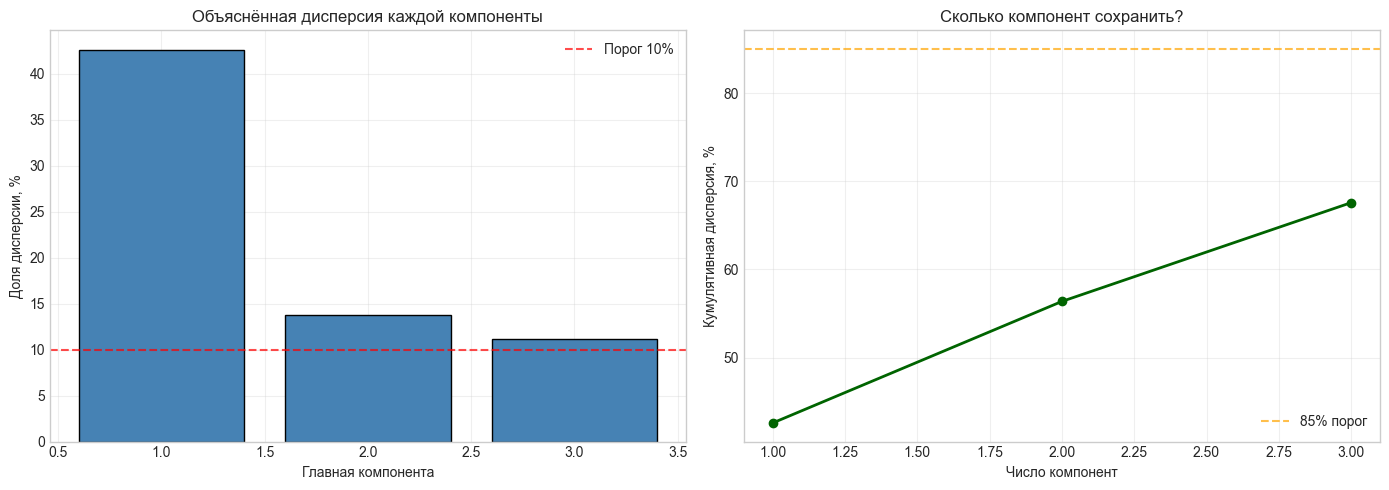

Для сохранения 85% дисперсии достаточно 1 компонент из 7


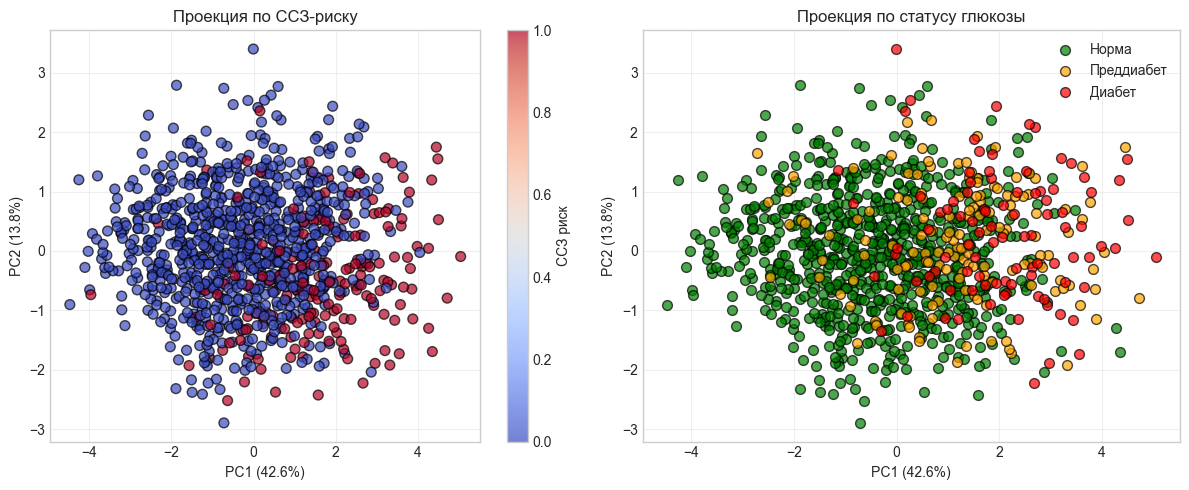

In [4]:
# Выбираем признаки для PCA (без целевых переменных)
features_pca = [
    'ИМТ', 'Окружность_талии_см', 'САД_мм_рт_ст', 
    'Глюкоза_натощак_ммоль_л', 'ЛПНП_ммоль_л', 
    'ЛПВП_ммоль_л', 'Триглицериды_ммоль_л'
]

# Подготовка данных
X_pca = df[features_pca].fillna(df[features_pca].mean())
X_pca_scaled = StandardScaler().fit_transform(X_pca)

# Применение PCA
pca = PCA(n_components=3)
X_pca_transformed = pca.fit_transform(X_pca_scaled)

# Визуализация объяснённой дисперсии
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Доля дисперсии по компонентам
axes[0].bar(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_ * 100,
    color='steelblue', edgecolor='black'
)
axes[0].axhline(y=10, color='red', linestyle='--', alpha=0.7, label='Порог 10%')
axes[0].set_xlabel('Главная компонента')
axes[0].set_ylabel('Доля дисперсии, %')
axes[0].set_title('Объяснённая дисперсия каждой компоненты')
axes[0].legend()
axes[0].grid(alpha=0.3)

# График 2: Кумулятивная дисперсия
cumulative = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(
    range(1, len(cumulative) + 1), cumulative,
    marker='o', color='darkgreen', linewidth=2
)
axes[1].axhline(y=85, color='orange', linestyle='--', alpha=0.7, label='85% порог')
axes[1].set_xlabel('Число компонент')
axes[1].set_ylabel('Кумулятивная дисперсия, %')
axes[1].set_title('Сколько компонент сохранить?')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Для сохранения 85% дисперсии достаточно "
      f"{np.argmax(cumulative >= 85) + 1} компонент из {len(features_pca)}")

# Визуализация проекций (PC1 vs PC2)
plt.figure(figsize=(12, 5))

# Распределение по ССЗ-риску
plt.subplot(1, 2, 1)
scatter = plt.scatter(
    X_pca_transformed[:, 0], X_pca_transformed[:, 1],
    c=df['ССЗ_риск_высокий'], cmap='coolwarm', s=50, alpha=0.7, edgecolors='k'
)
plt.colorbar(scatter, label='ССЗ риск')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Проекция по ССЗ-риску')
plt.grid(alpha=0.3)

# Распределение по статусу глюкозы
plt.subplot(1, 2, 2)
colors = {0: 'green', 1: 'orange', 2: 'red'}
for status, color in colors.items():
    mask = df['Статус_глюкозы'] == status
    plt.scatter(
        X_pca_transformed[mask, 0], X_pca_transformed[mask, 1],
        c=color, label=['Норма', 'Преддиабет', 'Диабет'][status],
        s=50, alpha=0.7, edgecolors='k'
    )
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Проекция по статусу глюкозы')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#  ЗАДАНИЕ ДЛЯ УЛУЧШЕНИЯ:
# Проанализируйте loadings (нагрузки) компонент для интерпретации
# Попробуйте визуализировать 3D-проекции (PC1, PC2, PC3)
# Добавьте анализ пациентов с "доклиническим риском" 

##  SVM: Прогнозирование сердечно-сосудистого риска

In [ ]:
# Подготовка данных для SVM
features_svm = [
    'ИМТ', 'Окружность_талии_см', 'САД_мм_рт_ст', 'ДАД_мм_рт_ст',
    'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Триглицериды_ммоль_л', 'Курение'
]

X_svm = df[features_svm].fillna(df[features_svm].mean())
y_svm = df['ССЗ_риск_высокий'].values

# Стандартизация и разделение
X_svm_scaled = StandardScaler().fit_transform(X_svm)
X_train, X_test, y_train, y_test = train_test_split(
    X_svm_scaled, y_svm, test_size=0.3, random_state=42, stratify=y_svm
)

print(f" Обучающая выборка: {len(X_train)} ({y_train.mean():.1%} высокого риска)")
print(f" Тестовая выборка: {len(X_test)} ({y_test.mean():.1%} высокого риска)")

# Обучение SVM модели
svm_model = SVC(
    kernel='rbf', C=1.0, gamma='scale',
    class_weight='balanced', probability=True, random_state=42
)
svm_model.fit(X_train, y_train)

# Прогнозы
y_pred = svm_model.predict(X_test)
y_proba = svm_model.predict_proba(X_test)[:, 1]

#  Оценка качества модели
print(f"\n🔹 МЕТРИКИ КАЧЕСТВА:")
print(f"  Accuracy:   {accuracy_score(y_test, y_pred):.3f}")
print(f"  Precision:  {precision_score(y_test, y_pred):.3f}")
print(f"  Recall:     {recall_score(y_test, y_pred):.3f}")
print(f"  F1-score:   {f1_score(y_test, y_pred):.3f}")
print(f"  ROC-AUC:    {auc(*roc_curve(y_test, y_proba)[:2]):.3f}")

#  Визуализация результатов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Низкий', 'Высокий'],
            yticklabels=['Низкий', 'Высокий'])
axes[0].set_title('Матрица ошибок')
axes[0].set_ylabel('Истинный класс')
axes[0].set_xlabel('Предсказанный класс')

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Случайный')
axes[1].set_xlabel('1 - Специфичность')
axes[1].set_ylabel('Чувствительность')
axes[1].set_title('ROC-кривая')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#  ЗАДАНИЕ ДЛЯ УЛУЧШЕНИЯ:
# Добавьте кросс-валидацию для оценки устойчивости модели
# Реализуйте подбор гиперпараметров (GridSearchCV)
# Проанализируйте важность признаков (через permutation importance)
# Добавьте анализ порогов классификации для разных клинических сценариев

## Fuzzy KNN: Оценка неопределённости риска диабета

In [ ]:
# Целевая группа: пациенты с пограничной глюкозой (5.4–6.5 ммоль/л)
df_target = df[
    (df['Глюкоза_натощак_ммоль_л'] >= 5.4) & 
    (df['Глюкоза_натощак_ммоль_л'] <= 6.5)
].copy()

print(f" Целевая группа: {len(df_target)} пациентов ({len(df_target)/len(df):.1%})")

# Признаки для Fuzzy KNN
features_fuzzy = [
    'Глюкоза_натощак_ммоль_л', 'ИМТ', 'Окружность_талии_см',
    'ЛПНП_ммоль_л', 'Триглицериды_ммоль_л'
]

# Подготовка данных
X_fuzzy = df_target[features_fuzzy].fillna(df_target[features_fuzzy].mean())
X_fuzzy_scaled = StandardScaler().fit_transform(X_fuzzy)
y_fuzzy = df_target['Статус_глюкозы'].values

# Разделение выборки
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fuzzy_scaled, y_fuzzy, test_size=0.3, random_state=42, stratify=y_fuzzy
)

#  Реализация простого Fuzzy KNN
class SimpleFuzzyKNN:
    """Базовая реализация нечёткого KNN для обучения"""
    
    def __init__(self, k=7, m=2.0):
        self.k = k
        self.m = m
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y.astype(int)
        self.classes_ = np.unique(y)
        return self
    
    def predict_membership(self, X):
        """Прогноз степеней принадлежности к классам"""
        memberships = np.zeros((X.shape[0], len(self.classes_)))
        
        for i in range(X.shape[0]):
            # Вычисление расстояний
            distances = np.sqrt(np.sum((X[i] - self.X_train) ** 2, axis=1))
            # k ближайших соседей
            idx = np.argsort(distances)[:self.k]
            dists = np.maximum(distances[idx], 1e-10)
            # Веса и агрегация
            weights = 1.0 / (dists ** self.m)
            
            for c in self.classes_:
                mask = self.y_train[idx] == c
                memberships[i, c] = np.sum(weights[mask])
            
            # Нормализация
            if np.sum(memberships[i]) > 0:
                memberships[i] /= np.sum(memberships[i])
                
        return memberships
    
    def predict_risk_score(self, X):
        """Расчёт скор риска прогрессии в диабет"""
        memberships = self.predict_membership(X)
        # Риск = 0.5 × принадлежность к преддиабету + 1.0 × к диабету
        risk_score = memberships[:, 1] * 0.5 + memberships[:, 2] * 1.0
        return risk_score, memberships

# Обучение и прогноз
fuzzy_model = SimpleFuzzyKNN(k=7, m=2.0)
fuzzy_model.fit(X_train_f, y_train_f)

risk_scores, memberships = fuzzy_model.predict_risk_score(X_test_f)

#  Визуализация результатов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение скоров риска
axes[0].hist(risk_scores, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.3, color='green', linestyle='--', label='Низкий риск (<30%)')
axes[0].axvline(x=0.7, color='red', linestyle='--', label='Высокий риск (≥70%)')
axes[0].set_xlabel('Скор риска')
axes[0].set_ylabel('Количество пациентов')
axes[0].set_title('Распределение скоров риска')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Пример принадлежности для пациента
example_idx = 0
colors = ['green', 'orange', 'red']
axes[1].bar(['Норма', 'Преддиабет', 'Диабет'], 
           memberships[example_idx], 
           color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Степень принадлежности')
axes[1].set_title(f'Пример пациента:\nРиск = {risk_scores[example_idx]:.1%}')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#  ЗАДАНИЕ ДЛЯ УЛУЧШЕНИЯ:
# Добавьте метрики качества для нечёткой классификации
# Реализуйте визуализацию неопределённости прогнозов
# Сравните результаты с "жёсткой" классификацией
# Добавьте интерактивную визуализацию для анализа отдельных пациентов

##  Сводная таблица результатов

In [ ]:
# Сводка по всем моделям
results = {
    'Модель': ['PCA', 'SVM', 'Fuzzy KNN'],
    'Задача': [
        'Выявление профилей риска',
        'Прогноз ССЗ-риска',
        'Оценка риска диабета'
    ],
    'Ключевая метрика': [
        f'{pca.explained_variance_ratio_[0]:.1%} (PC1)',
        f'{auc(*roc_curve(y_test, y_proba)[:2]):.3f} (ROC-AUC)',
        f'{np.mean(risk_scores):.1%} (средний риск)'
    ],
    'Интерпретируемость': ['Высокая', 'Средняя', 'Высокая'],
    'Рекомендация для улучшения': [
        'Добавить 3D-визуализацию',
        'Кросс-валидация + GridSearch',
        'Анализ неопределённости'
    ]
}

results_df = pd.DataFrame(results)
display(results_df)

print("\n Базовое решение готово!")
print("\n Следующие шаги для обучающегося:")
print("1. Выберите одну модель для углублённой доработки")
print("2. Добавьте кросс-валидацию и подбор гиперпараметров")
print("3. Улучшите визуализации для лучшей интерпретации")
print("4. Подготовьте краткий отчёт с клиническими рекомендациями")

##  Чек-лист для улучшения решения

###  Базовый уровень (обязательно)
- [ ] Добавить обработку выбросов в данных
- [ ] Визуализировать корреляционную матрицу признаков
- [ ] Оформить код в функции для повторного использования

###  Продвинутый уровень (рекомендуется)
- [ ] Реализовать кросс-валидацию для SVM
- [ ] Добавить подбор гиперпараметров (GridSearchCV)
- [ ] Визуализировать loadings PCA для интерпретации компонент
- [ ] Добавить анализ калибровки вероятностей для SVM

### Экспертный уровень (для портфолио)
- [ ] Реализовать пайплайн предобработки + модели
- [ ] Создать интерактивный дашборд (Plotly/Dash)
- [ ] Написать unit-тесты для ключевых функций

---

>  **Примечание**: Это базовое решение намеренно упрощено для учебных целей. В реальном проекте необходимо:
> - Валидировать модели на независимых данных
> - Учитывать этические аспекты и регулирование
> - Обеспечить воспроизводимость (фиксация random_state, версионирование)
> - Документировать все допущения и ограничения
